# VectorDrive-Route: End-to-End Trajectory Planning Pipeline Visualizations

This notebook walks through each stage of the `VectorDrive-Route` end-to-end multi-view camera-to-3D Bird's-Eye-View (BEV) trajectory planner. The pipeline processes synchronized front cameras, constructs a spatial-temporal BEV scene representation, and uses a query-based cross-attention head to select and refine safe driving trajectories.

Here is the pipeline architecture diagram from `README.md`:

```mermaid
graph TD
    CAM[Multi-Camera Front Feeds] -->|Cylindrical Projection| PAN[Panoramic Canvas]
    PAN -->|ResNet-18 Backbone| FEAT[Perspective Features]
    FEAT -->|LSS Lift Stage| FRUS[3D Frustum Space]
    FRUS -->|Voxel Pooling Splat| BEV[Current BEV Feature Map]
    BEV -->|Ego-Motion Warping + ConvGRU| FUSE[Fused Recurrent BEV State]
    FUSE -->|Cross-Attention| TRAJ[Trajectory Planner Head]
    TRAJ -->|Trajectory Offset Regressor| WAY[Refined Waypoints]
    TRAJ -->|Anchor Classifier| PROB[Path Probabilities]
    FUSE -->|Auxiliary Decoders| MAPS[Drivable & Occupancy Grids]
```

We will load a validation sample from the `nuScenes` dataset, load the pre-trained `checkpoints/best_model.pth` checkpoint, and visualize the intermediate inputs and outputs of each of the following 8 stages of the pipeline:
1. **Unified Cylindrical Canvas Stitching**
2. **Backbone Feature Extraction**
3. **Categorical Depth Lift (LSS)**
4. **Vectorized Voxel Pooling (Splat) & BEV Smoothing**
5. **Motion-Compensated Temporal Recurrent Fusion**
6. **Cross-Attention Trajectory Planning Head (Classification)**
7. **Cross-Attention Trajectory Planning Head (Regression)**
8. **Auxiliary Decoding & Safety Regularization**



## ⚙️ Environment Setup & Imports

Let's configure the environment, append the current workspace directory to the Python path, import the required modules, and set up the model/dataset.



In [24]:
import os
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

# Ensure project root is in path
sys.path.append(os.getcwd())

from datasets.nuscenes_dataset import NuscenesDataset
from models.model import VectorDriveRouteModel

# Set up device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on device: {device}")



Running on device: cpu


## 📦 Load Dataset and Checkpoint

We will load the `nuScenes-mini` validation dataset split and load the model weights from the pre-trained checkpoint `checkpoints/best_model.pth`.



In [25]:
# Load dataset
dataset = NuscenesDataset(
    version='v1.0-mini', 
    dataroot='data/nuscenes', 
    split='val', 
    downscale_factor=2
)
print(f"Loaded validation split with {len(dataset)} samples.")

# Load pre-trained checkpoint
checkpoint_path = "checkpoints/best_model.pth"
if os.path.exists(checkpoint_path):
    print(f"Loading checkpoint from {checkpoint_path}...")
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    anchors = checkpoint['anchors']
    model = VectorDriveRouteModel(anchors=anchors).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    raise FileNotFoundError(f"Checkpoint not found at {checkpoint_path}. Please run train or verify evaluation first.")

model.eval()
print("Model loaded and set to evaluation mode.")



Loaded validation split with 130 samples.
Loading checkpoint from checkpoints/best_model.pth...
Model loaded and set to evaluation mode.


## 🚗 Fetch Consecutive Test Samples for Recurrent Fusion

To demonstrate temporal recurrence and motion-compensated warping, we will fetch two consecutive samples (`sample_0` at $t-1$ and `sample_1` at $t$) from the validation dataset.



In [26]:
# Get consecutive samples (same scene validation split)
sample_0 = dataset[0]
sample_1 = dataset[1]

# Package sample_1 into batch dimension for model input
images_1 = sample_1['images'].unsqueeze(0).to(device)
intrinsics_1 = sample_1['intrinsics'].unsqueeze(0).to(device)
extrinsics_1 = sample_1['extrinsics'].unsqueeze(0).to(device)
ego_state_1 = sample_1['ego_state'].unsqueeze(0).to(device)

print("Fetched consecutive samples from NuScenes dataset.")
print(f"Ego vehicle current velocity (vx): {sample_1['ego_state'][0].item():.2f} m/s")
print(f"Ego vehicle current yaw rate: {sample_1['ego_state'][1].item():.2f} rad/s")



Fetched consecutive samples from NuScenes dataset.
Ego vehicle current velocity (vx): 0.00 m/s
Ego vehicle current yaw rate: 0.00 rad/s


---
## 🌐 Stage 1: Unified Cylindrical Canvas Stitching

### Explanation
To eliminate redundant overlapping camera pixels and projection seams, `VectorDrive-Route` maps the three front-facing cameras (`CAM_FRONT_LEFT`, `CAM_FRONT`, `CAM_FRONT_RIGHT`) into a unified **180-degree Virtual Cylindrical Canvas** panorama.

#### Coordinate Mapping
Let $(u_{cyl}, v_{cyl})$ be the pixel coordinates on the cylindrical canvas of dimensions $H_{out} \times W_{out}$.
1. **Yaw ($\theta$) and Pitch ($\phi$) calculation**:
   $$\theta = \frac{\theta_{fov}}{2} - \left(\frac{u_{cyl}}{W_{out}}\right) \theta_{fov}$$
   $$\phi = \arctan\left(\frac{\frac{H_{out}}{2} - v_{cyl}}{f_{virtual}}\right)$$
   Where $f_{virtual} = \frac{H_{out}}{2 \tan(\phi_{fov} / 2)}$.
2. **Ray Casting**: Calculate the 3D direction vector $d_{ego} = [x_{ego}, y_{ego}, z_{ego}]^T$ in local Ego Frame (Forward $+X$, Left $+Y$, Up $+Z$):
   $$x_{ego} = \cos(\theta) \cos(\phi), \quad y_{ego} = \sin(\theta) \cos(\phi), \quad z_{ego} = \sin(\phi)$$
3. **Projection & Bilinear Sampling**: Project rays at $d_{default} = 30.0\text{m}$ to obtain 3D camera frame coordinates and project them onto the original cameras' pixel coordinate frames for sampling.



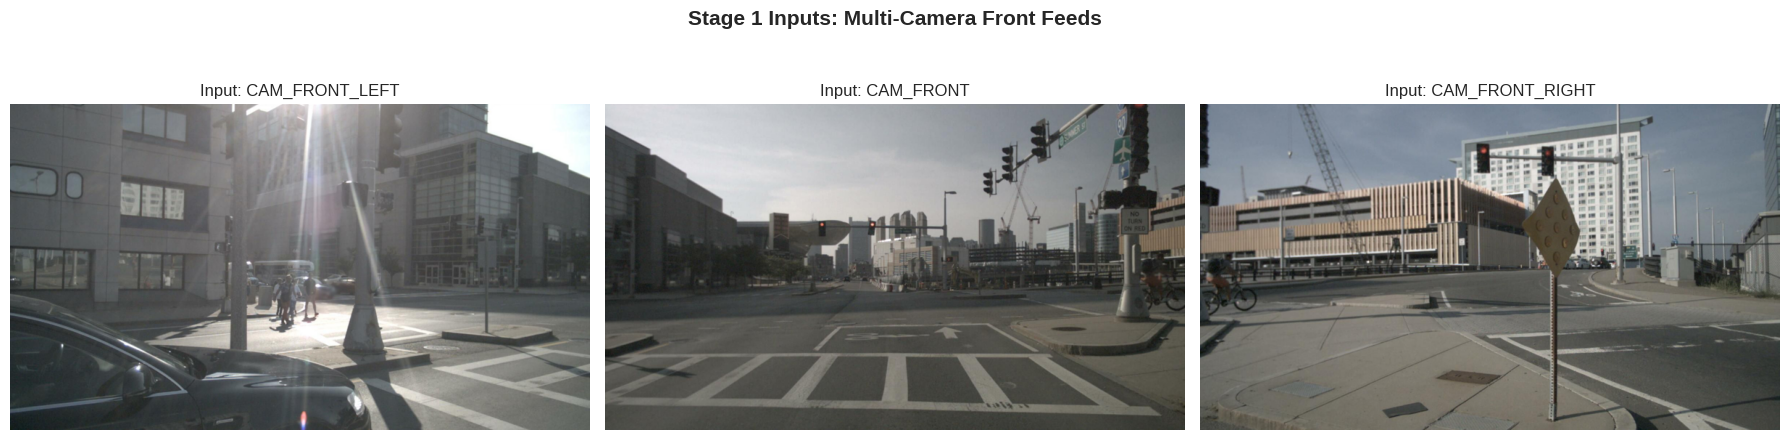

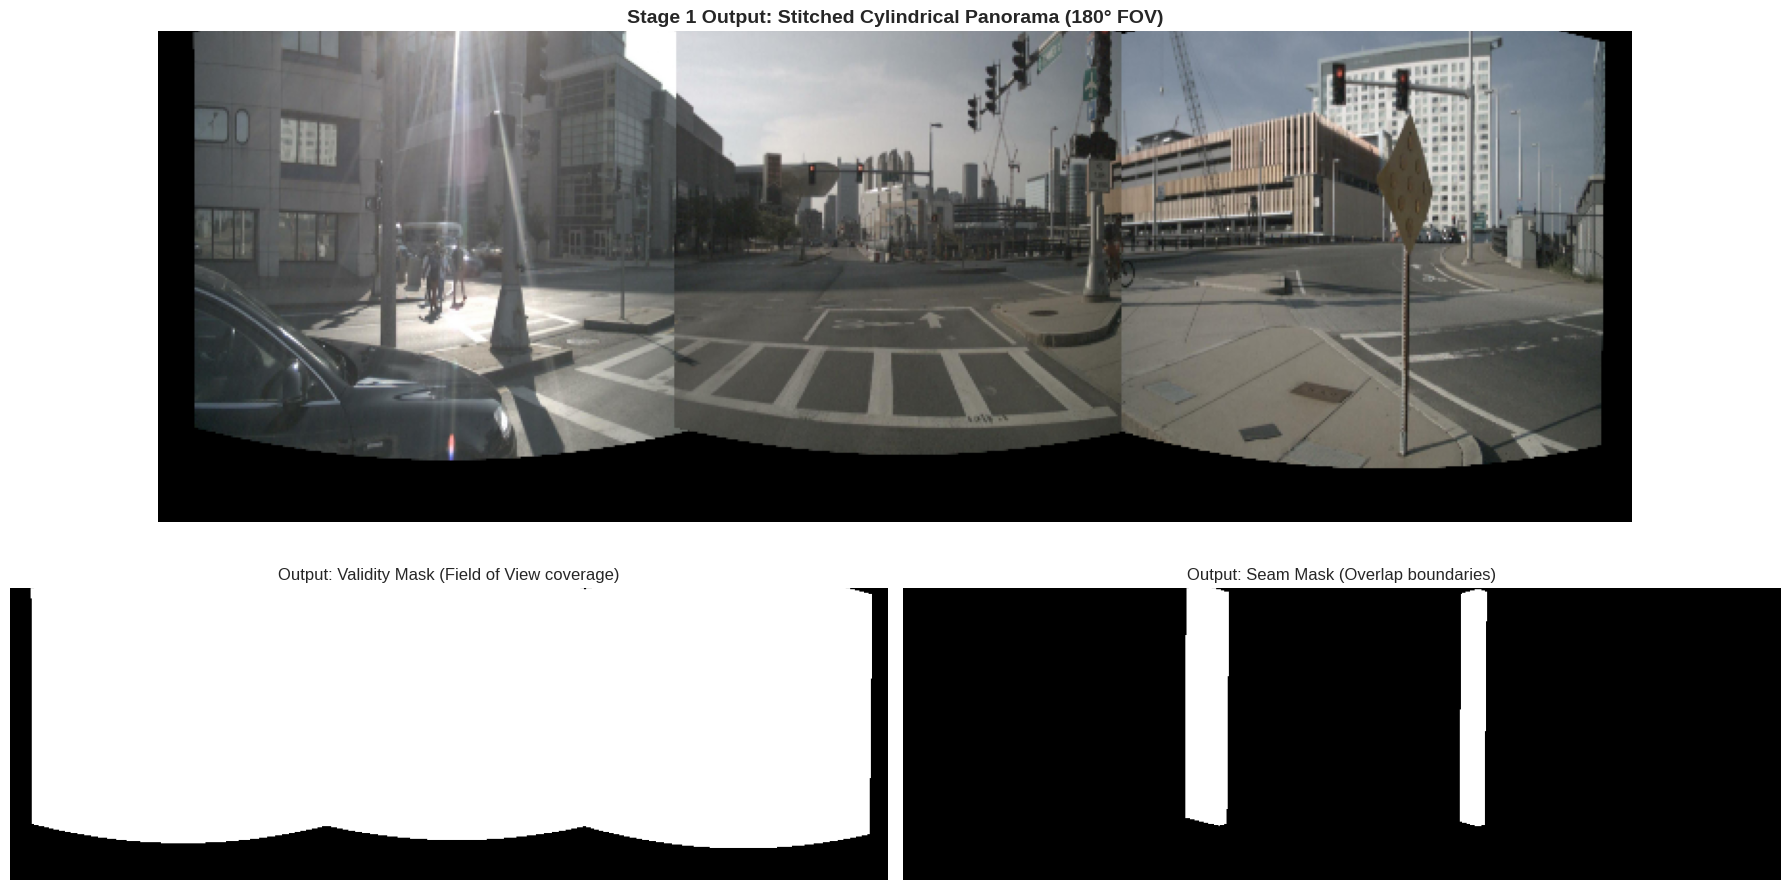

In [27]:
# Run cylindrical projection
with torch.no_grad():
    images_cyl_1, camera_mask_1, seam_mask_1, validity_mask_1 = model.projection(images_1, intrinsics_1, extrinsics_1)

# Visualize inputs: original 3 camera feeds
plt.figure(figsize=(18, 5))
cams = ['CAM_FRONT_LEFT', 'CAM_FRONT', 'CAM_FRONT_RIGHT']
for idx in range(3):
    plt.subplot(1, 3, idx + 1)
    img_np = sample_1['images'][idx].permute(1, 2, 0).numpy()
    plt.imshow(img_np)
    plt.title(f"Input: {cams[idx]}", fontsize=12)
    plt.axis('off')
plt.suptitle("Stage 1 Inputs: Multi-Camera Front Feeds", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Visualize output: stitched cylindrical panorama and masks
plt.figure(figsize=(18, 10))
plt.subplot(2, 1, 1)
plt.imshow(images_cyl_1[0].permute(1, 2, 0).cpu().numpy())
plt.title("Stage 1 Output: Stitched Cylindrical Panorama (180° FOV)", fontsize=14, fontweight='bold')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(validity_mask_1[0, 0].cpu().numpy(), cmap='gray')
plt.title("Output: Validity Mask (Field of View coverage)", fontsize=12)
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(seam_mask_1[0, 0].cpu().numpy(), cmap='gray')
plt.title("Output: Seam Mask (Overlap boundaries)", fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.show()



---
## 🧠 Stage 2: Panoramic Canvas to Perspective Features (ResNet-18 Backbone)

### Explanation
The stitched cylindrical panorama is processed by a 2D CNN backbone (adapted from `ResNet-18`) to extract dense perspective features.

- **Input Tensor**: Cylindrical canvas image $I_{cyl} \in \mathbb{R}^{B \times 3 \times H_{out} \times W_{out}}$.
- **Backbone layers**: Extracted stride-4 features from Layer 1 and stride-8 features from Layer 2.
- **Projection Layer**: A $3\times3$ convolution layer maps the 128 channels of Layer 2 to $C_{feat} = 256$ features.
- **Output Tensor**: Stride-8 perspective features $F_{feat} \in \mathbb{R}^{B \times C_{feat} \times H_{feat} \times W_{feat}}$ ($32 \times 96$ feature resolution).



Stitched Cylindrical Input Shape: torch.Size([1, 3, 256, 768])
Perspective Features Output Shape: torch.Size([1, 256, 32, 96])


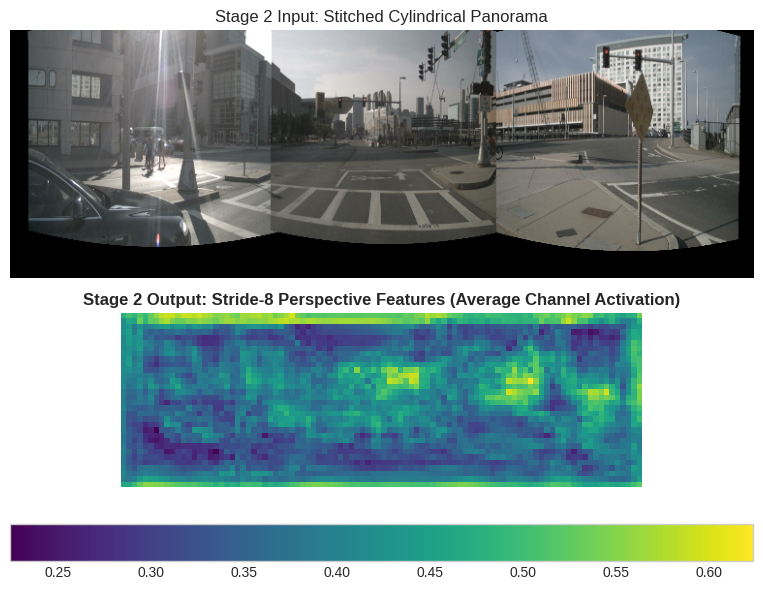

In [28]:
# Run backbone feature extraction
with torch.no_grad():
    feat_1 = model.backbone(images_cyl_1)
print(f"Stitched Cylindrical Input Shape: {images_cyl_1.shape}")
print(f"Perspective Features Output Shape: {feat_1.shape}")

# Visualize feature activations (mean along channels)
feat_mean_1 = torch.mean(feat_1[0], dim=0).detach().cpu().numpy()

plt.figure(figsize=(18, 6))
plt.subplot(2, 1, 1)
plt.imshow(images_cyl_1[0].permute(1, 2, 0).cpu().numpy())
plt.title("Stage 2 Input: Stitched Cylindrical Panorama", fontsize=12)
plt.axis('off')

plt.subplot(2, 1, 2)
plt.imshow(feat_mean_1, cmap='viridis', aspect='equal')
plt.title("Stage 2 Output: Stride-8 Perspective Features (Average Channel Activation)", fontsize=12, fontweight='bold')
plt.colorbar(orientation='horizontal', pad=0.15)
plt.axis('off')
plt.tight_layout()
plt.show()



---
## 📐 Stage 3: Perspective Features to 3D Frustum Space (LSS Lift Stage)

### Explanation
The model uses a **Depth-Conditioned Lift-Splat-Shoot (LSS)** layer to map 2D perspective features into a 3D frustum space.

1. **Context Head**: Maps perspective features to context tokens of dimension $C_{context} = 80$.
2. **Depth Head**: Predicts categorical depth probabilities over $D_{bins} = 40$ bins (from 2.0m to 42.0m in steps of 1.0m) using channel-wise Softmax:
   $$D_{probs} = \text{Softmax}(\text{DepthLogits})$$
3. **Lifting Outer Product**: Broadcast and multiply the context features by the depth probabilities to form the 3D frustum:
   $$\text{Frustum}(b, c, d, h, w) = \text{Context}(b, c, h, w) \times D_{probs}(b, d, h, w)$$
   Output tensor shape: `[B, C_context=80, D_bins=40, H_feat=32, W_feat=96]`.



Perspective Features Input Shape: torch.Size([1, 256, 32, 96])
Frustum Tensor Output Shape: torch.Size([1, 80, 40, 32, 96])
Depth Probabilities Output Shape: torch.Size([1, 40, 32, 96])


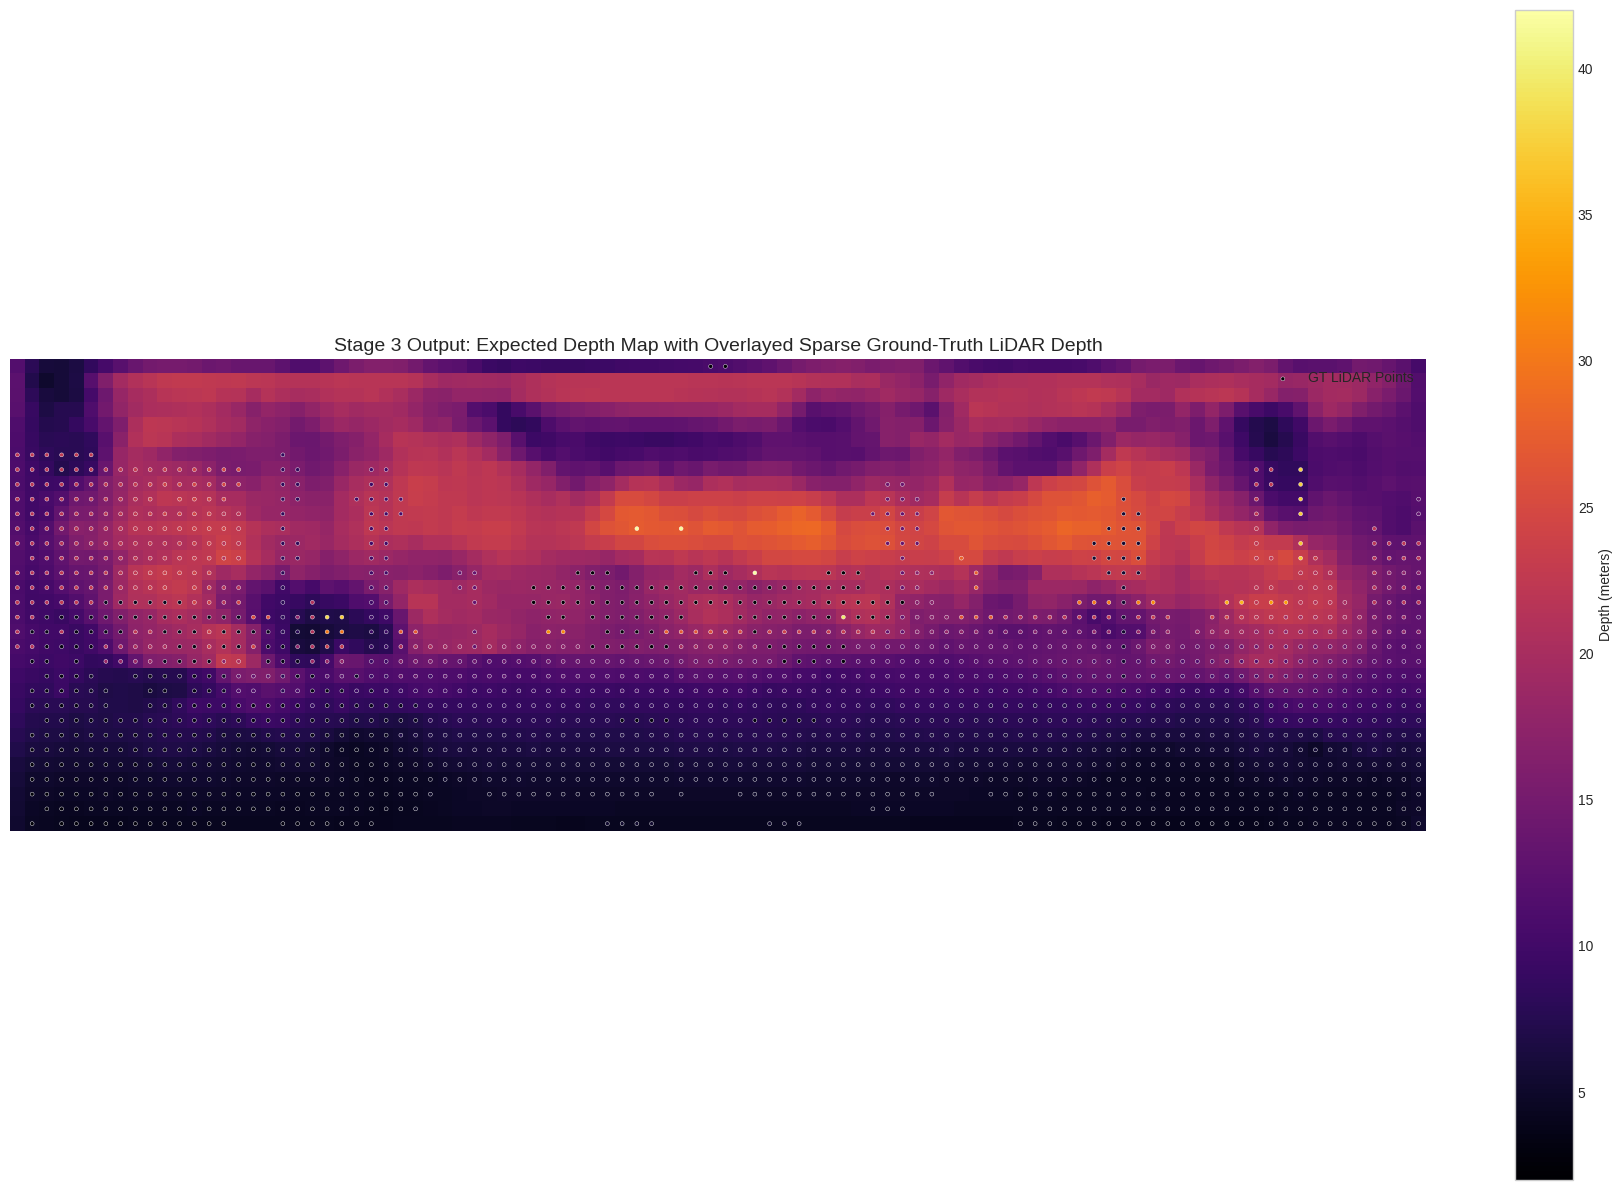

In [29]:
# Run lifting stage
with torch.no_grad():
    frustum_1, depth_probs_1 = model.lift(feat_1)
print(f"Perspective Features Input Shape: {feat_1.shape}")
print(f"Frustum Tensor Output Shape: {frustum_1.shape}")
print(f"Depth Probabilities Output Shape: {depth_probs_1.shape}")

# Calculate expected depth map for visualization: sum_d (probs_d * depth_d)
depth_bins = torch.linspace(2.0, 42.0, 40, device=device).view(40, 1, 1)
expected_depth_1 = torch.sum(depth_probs_1[0] * depth_bins, dim=0).detach().cpu().numpy()

# Retrieve ground truth depth targets from sparse LiDAR sweeps
gt_depth_1 = sample_1['depth_target'][0].numpy()
depth_mask_1 = sample_1['depth_mask'][0].numpy()

plt.figure(figsize=(18, 12))

# Predicted Depth overlayed with sparse LiDAR ground-truth depth
plt.imshow(expected_depth_1, cmap='inferno', vmin=2.0, vmax=42.0, aspect='equal')
y_indices, x_indices = np.where(depth_mask_1 > 0.5)
if len(x_indices) > 0:
    plt.scatter(x_indices, y_indices, c=gt_depth_1[y_indices, x_indices], cmap='inferno', 
                s=8, edgecolors='white', linewidths=0.3, label="GT LiDAR Points")
plt.title("Stage 3 Output: Expected Depth Map with Overlayed Sparse Ground-Truth LiDAR Depth", fontsize=14)
plt.colorbar(label="Depth (meters)")
plt.legend()
plt.axis('off')
plt.tight_layout()
plt.show()



---
## 🗺️ Stage 4: 3D Frustum Space to Current BEV Feature Map (Voxel Pooling Splat & Smoothing)

### Explanation
Voxel pooling projects (splats) the 3D frustum features onto a top-down, ego-centric 2D Bird's-Eye-View (BEV) grid.

1. **Coordinate Projection**: Map 3D frustum cells to the $100 \times 100$ BEV grid cells (covering $X \in [-20.0, 20.0]$m, $Y \in [0.0, 40.0]$m at 0.4m resolution).
2. **Vectorized Pooling**: Accumulate features falling in the same grid cell using `torch.scatter_add_` based on a precomputed indexing lookup map.
3. **BEV ResBlocks (Lateral Smoothing)**: Smearing features along projection rays generates radial fan-shaped noise streaks. The pipeline deploys two sequential `BEVResBlock` blocks to allow adjacent spatial grids to share features, smoothing out projection streaks.



Frustum Input Shape: torch.Size([1, 80, 40, 32, 96])
Raw BEV Features Output Shape: torch.Size([1, 80, 100, 100])
Smoothed BEV Features Output Shape: torch.Size([1, 80, 100, 100])


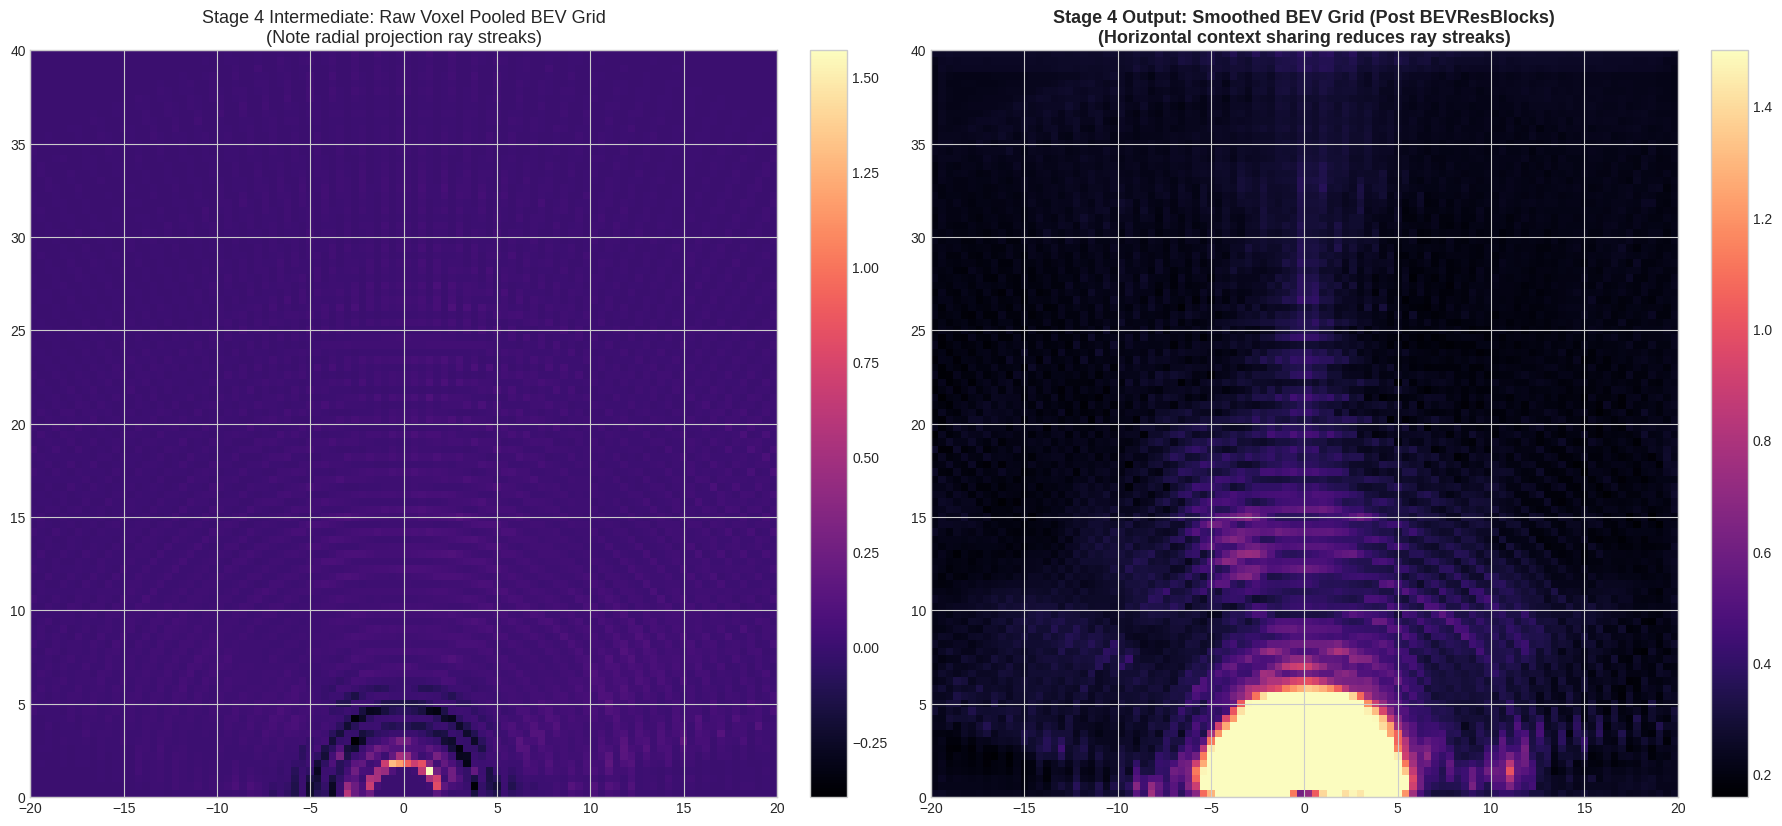

In [30]:
# Run voxel pooling and smoothing
with torch.no_grad():
    x_bev_raw_1 = model.pool(frustum_1)
    x_bev_smoothed_1 = model.bev_smooth(x_bev_raw_1)

print(f"Frustum Input Shape: {frustum_1.shape}")
print(f"Raw BEV Features Output Shape: {x_bev_raw_1.shape}")
print(f"Smoothed BEV Features Output Shape: {x_bev_smoothed_1.shape}")

# Visualize raw vs smoothed BEV features (average across channels)
raw_bev_np = torch.mean(x_bev_raw_1[0], dim=0).detach().cpu().numpy()
smooth_bev_np = torch.mean(x_bev_smoothed_1[0], dim=0).detach().cpu().numpy()

plt.figure(figsize=(18, 8))
plt.subplot(1, 2, 1)
plt.imshow(raw_bev_np, cmap='magma', origin='upper', extent=[-20, 20, 0, 40])
plt.title("Stage 4 Intermediate: Raw Voxel Pooled BEV Grid\n(Note radial projection ray streaks)", fontsize=13)
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(1, 2, 2)
plt.imshow(smooth_bev_np, cmap='magma', origin='upper', extent=[-20, 20, 0, 40], vmax=1.5)
plt.title("Stage 4 Output: Smoothed BEV Grid (Post BEVResBlocks)\n(Horizontal context sharing reduces ray streaks)", fontsize=13, fontweight='bold')
plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()



---
## 🔄 Stage 5: Ego-Motion Warping + ConvGRU (Fused Recurrent BEV State)

### Explanation
To build a consistent spatial-temporal state representation, historical features must be realigned with the current ego coordinate frame using local localization logs before recurrence.

1. **Analytical Warping**: Using the forward velocity $v_x$ and yaw rate $\omega$ over the interval $dt = 0.5\text{s}$, compute the $2 \times 3$ affine warping matrix $M_{warp}$:
   $$M_{warp} = \begin{bmatrix} \cos(d\theta) & \sin(d\theta) & -50.0 \cos(d\theta) + 50.0 \\ -\sin(d\theta) & \cos(d\theta) & 50.0 \sin(d\theta) - 2.5 dy \end{bmatrix}$$
   Apply the transformation to the previous state using bilinear interpolation.
2. **Recurrent Fusion**: A spatial `ConvGRU` cell fuses the current smoothed BEV feature map and the warped previous state.



Temporal fusion execution complete.
Previous BEV shape: torch.Size([1, 80, 100, 100])
Warped previous BEV shape: torch.Size([1, 80, 100, 100])
Fused state shape: torch.Size([1, 80, 100, 100])


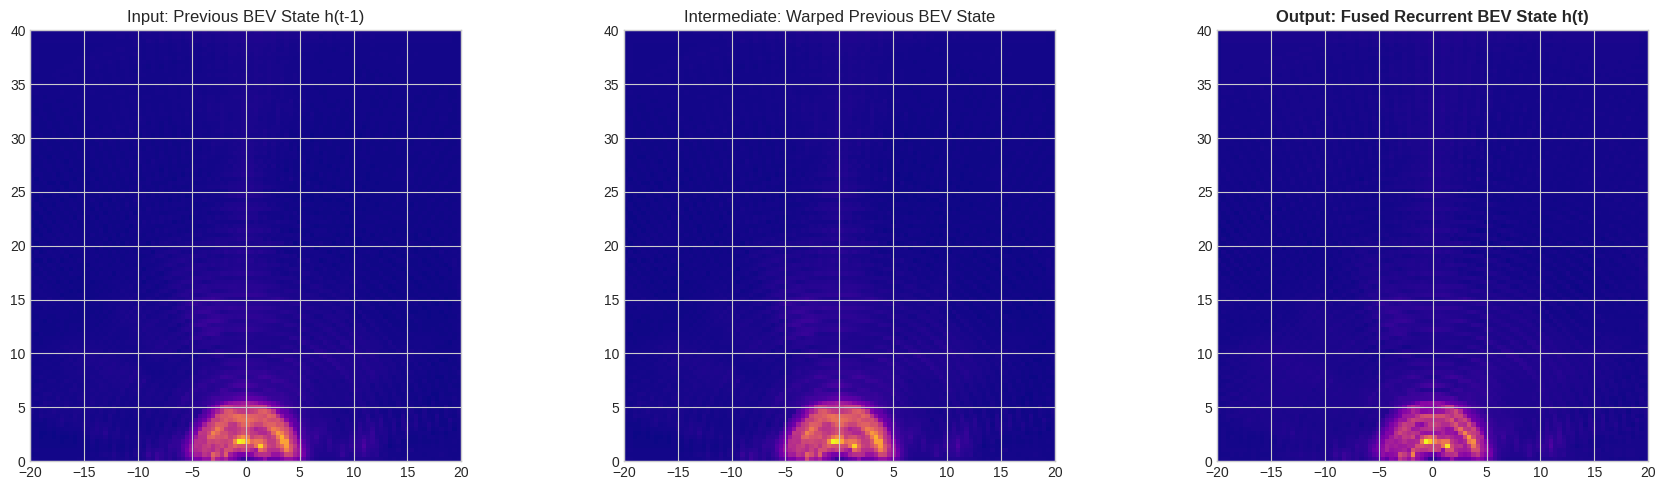

In [31]:
# Run previous sample to get its smoothed BEV representation
images_0 = sample_0['images'].unsqueeze(0).to(device)
intrinsics_0 = sample_0['intrinsics'].unsqueeze(0).to(device)
extrinsics_0 = sample_0['extrinsics'].unsqueeze(0).to(device)

with torch.no_grad():
    cyl_0, _, _, _ = model.projection(images_0, intrinsics_0, extrinsics_0)
    feat_0 = model.backbone(cyl_0)
    frustum_0, _ = model.lift(feat_0)
    x_bev_raw_0 = model.pool(frustum_0)
    x_bev_smoothed_0 = model.bev_smooth(x_bev_raw_0)

# Compute warp matrix and warp previous hidden state
from models.temporal_fusion import compute_warp_matrix
import kornia

with torch.no_grad():
    M_warp = compute_warp_matrix(ego_state_1, dt=0.5)
    # Warp previous BEV state
    h_prev_warped = kornia.geometry.transform.warp_affine(
        x_bev_smoothed_0, M_warp, dsize=(100, 100), mode='bilinear', padding_mode='zeros'
    )
    # Recurrent update
    h_next_1 = model.temporal_fusion(x_bev_smoothed_1, x_bev_smoothed_0, ego_state_1)

print("Temporal fusion execution complete.")
print(f"Previous BEV shape: {x_bev_smoothed_0.shape}")
print(f"Warped previous BEV shape: {h_prev_warped.shape}")
print(f"Fused state shape: {h_next_1.shape}")

# Visualize the warping sequence
prev_np = torch.mean(x_bev_smoothed_0[0], dim=0).detach().cpu().numpy()
warped_np = torch.mean(h_prev_warped[0], dim=0).detach().cpu().numpy()
fused_np = torch.mean(h_next_1[0], dim=0).detach().cpu().numpy()

plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.imshow(prev_np, cmap='plasma', origin='upper', extent=[-20, 20, 0, 40])
plt.title("Input: Previous BEV State h(t-1)", fontsize=12)

plt.subplot(1, 3, 2)
plt.imshow(warped_np, cmap='plasma', origin='upper', extent=[-20, 20, 0, 40])
plt.title("Intermediate: Warped Previous BEV State", fontsize=12)

plt.subplot(1, 3, 3)
plt.imshow(fused_np, cmap='plasma', origin='upper', extent=[-20, 20, 0, 40])
plt.title("Output: Fused Recurrent BEV State h(t)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()



---
## 🎯 Stage 6 & 7: Trajectory Planner Head (Classification, Regression, and Choices)

### Explanation
The trajectory planner extracts Scene Tokens from the fused BEV features, maps static anchors to queries, and executes query-based cross-attention.

1. **BEV Compression**: Convolve and pool the fused BEV features down to 64 scene tokens of shape `[B, 64, C_trans=256]`.
2. **Anchor Projection**: Project the $K=16$ static trajectory anchors (generated offline via K-Means clustering of expert trajectories) into $16$ query tokens of shape `[B, 16, C_trans=256]`.
3. **Cross-Attention**: Query scene tokens using the anchor queries via multi-head cross-attention.
4. **Classification Head**: Classifies each query token to compute selection probability scores.
5. **Regression Head**: Regresses coordinate offsets ($\Delta P \in \mathbb{R}^{B \times 16 \times 8 \times 2}$) to refine the waypoints:
   $$P_{refined} = P_{anchor} + \Delta P$$



Chosen trajectory index: 15 with probability 0.8987


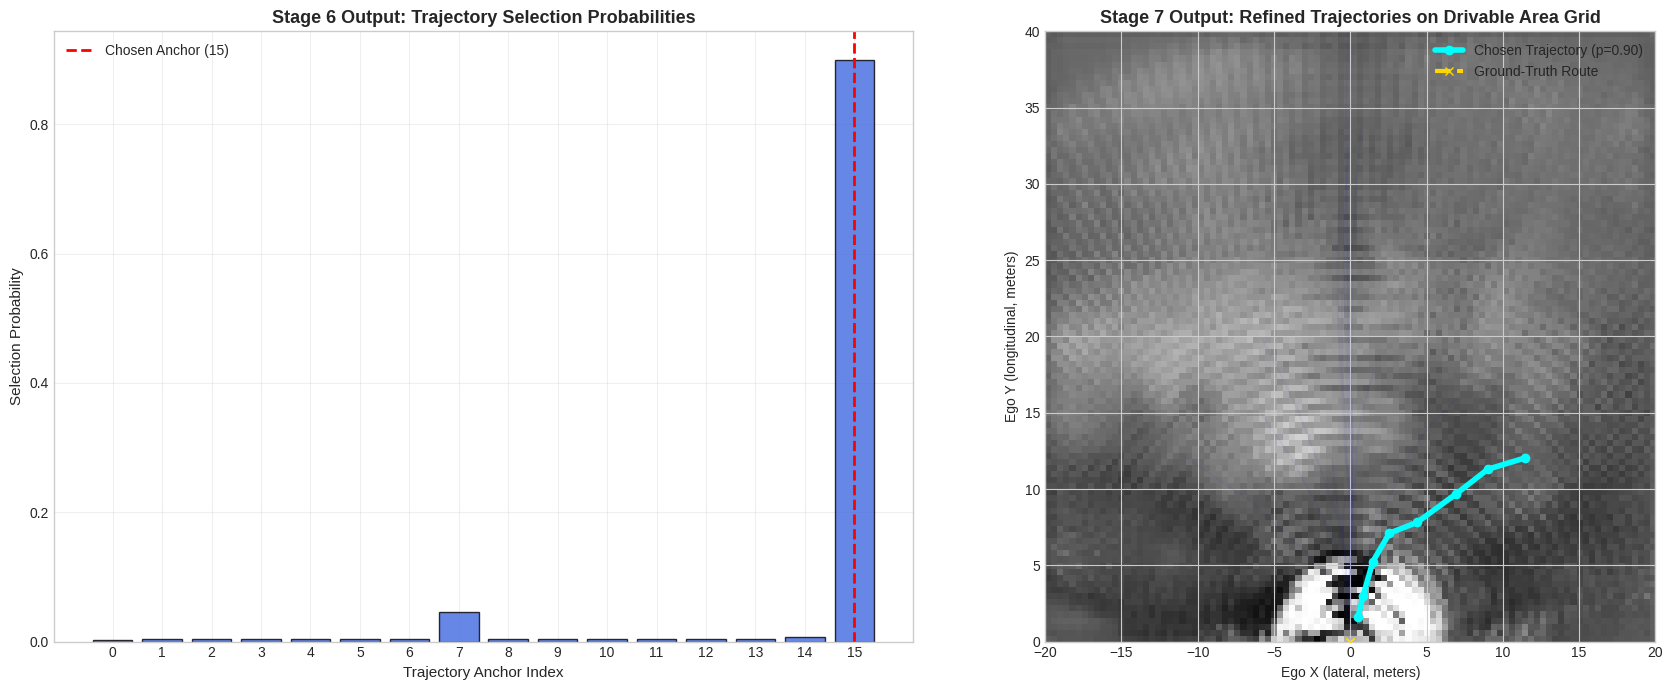

In [32]:
# Run planning head
with torch.no_grad():
    logits_1, trajectories_1, drivable_preds_1, occupancy_preds_1 = model.planning_head(h_next_1)

# Extract choice parameters
probs_1 = torch.softmax(logits_1[0], dim=0).detach().cpu().numpy()
trajectories_np_1 = trajectories_1[0].detach().cpu().numpy()
best_idx_1 = torch.argmax(logits_1[0]).item()
gt_traj_1 = sample_1['future_traj'].numpy()

print(f"Chosen trajectory index: {best_idx_1} with probability {probs_1[best_idx_1]:.4f}")

plt.figure(figsize=(18, 7))

# Subplot 1: Probability Distribution
plt.subplot(1, 2, 1)
plt.bar(range(16), probs_1, color='royalblue', edgecolor='k', alpha=0.8)
plt.axvline(best_idx_1, color='red', linestyle='--', linewidth=2, label=f'Chosen Anchor ({best_idx_1})')
plt.xticks(range(16))
plt.xlabel("Trajectory Anchor Index", fontsize=11)
plt.ylabel("Selection Probability", fontsize=11)
plt.title("Stage 6 Output: Trajectory Selection Probabilities", fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Trajectories visual plot
drivable_prob_1 = torch.sigmoid(drivable_preds_1[0, 0]).detach().cpu().numpy()
plt.subplot(1, 2, 2)
plt.imshow(drivable_prob_1, cmap='gray', origin='upper', extent=[-20, 20, 0, 40])

# Plot all candidate trajectories, fading out unselected ones
for k in range(16):
    grid_x = trajectories_np_1[k, :, 0]
    grid_y = trajectories_np_1[k, :, 1]
    
    alpha_val = max(0.1, probs_1[k] / probs_1.max())
    if k == best_idx_1:
        plt.plot(grid_x, grid_y, color='cyan', linewidth=4, marker='o', label=f'Chosen Trajectory (p={probs_1[k]:.2f})', zorder=5)
    else:
        plt.plot(grid_x, grid_y, color='blue', alpha=alpha_val * 0.4, linewidth=1.5, zorder=2)

# Plot ground-truth trajectory
gt_grid_x = gt_traj_1[:, 0]
gt_grid_y = gt_traj_1[:, 1]
plt.plot(gt_grid_x, gt_grid_y, color='gold', linewidth=3, linestyle='--', marker='x', label='Ground-Truth Route', zorder=6)

plt.title("Stage 7 Output: Refined Trajectories on Drivable Area Grid", fontsize=13, fontweight='bold')
plt.legend()
plt.xlim(-20, 20)
plt.ylim(0, 40)
plt.xlabel("Ego X (lateral, meters)")
plt.ylabel("Ego Y (longitudinal, meters)")
plt.tight_layout()
plt.show()



---
## 🗺️ Stage 8: Auxiliary Decoders & Safety Regularization

### Explanation
To enforce planning compliance and prevent the network from predicting paths through solid obstacles, parallel segmentation heads predict **drivable areas** and **obstacle occupancy** grids.

During training, these outputs supervise the intermediate features. In evaluation and path checking:
- **Drivable Area Compliance**: Measures the percentage of the trajectory waypoints that lie inside the drivable area.
- **Collision Rate**: Tracks occurrences where planned waypoints intersect predicted occupancy regions.



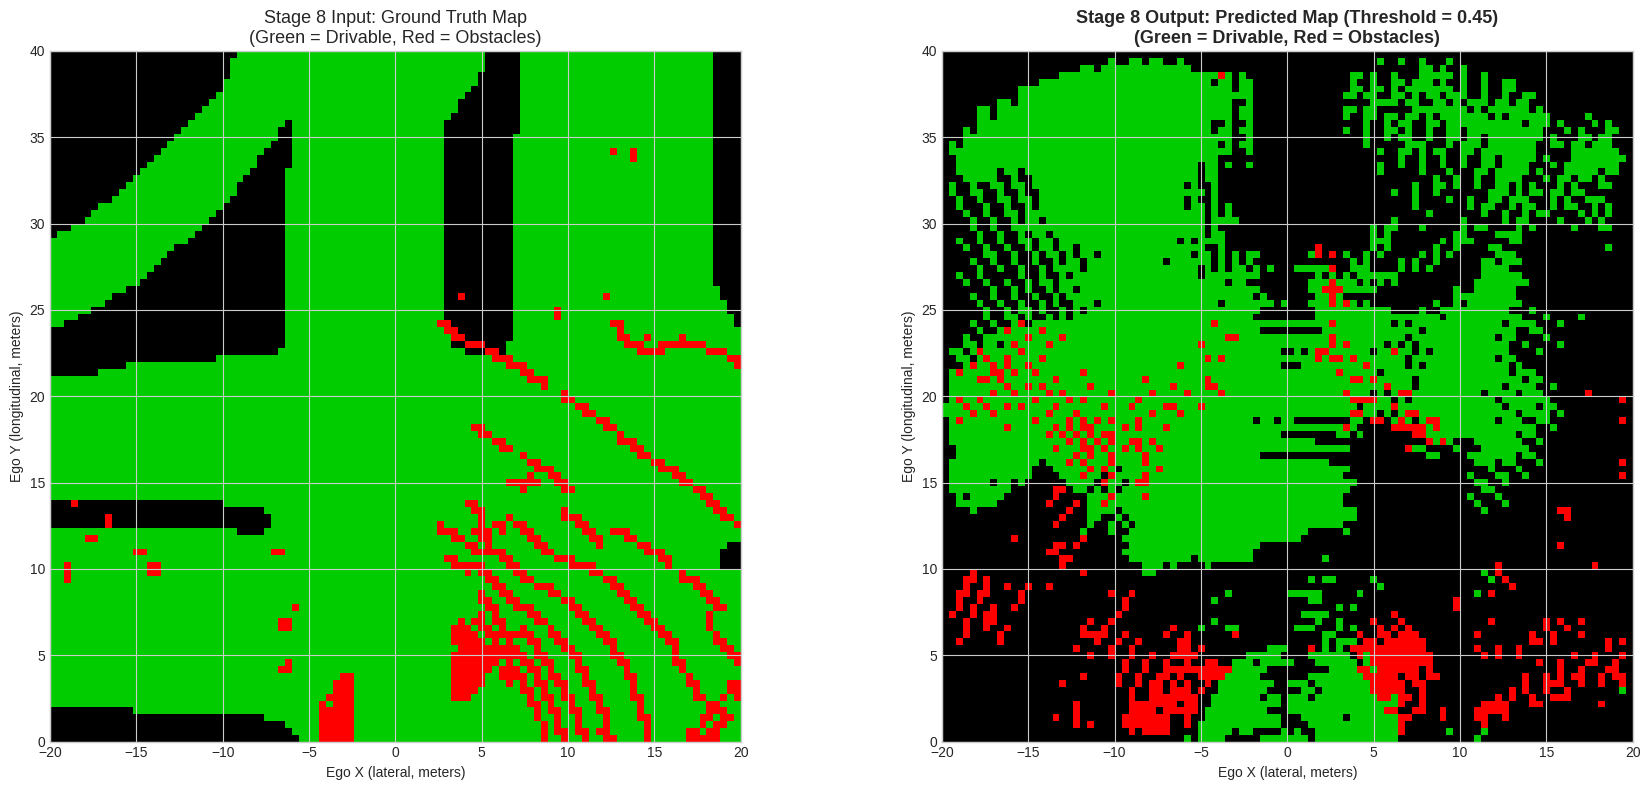

In [33]:
# Get prediction maps
drivable_pred_1 = torch.sigmoid(drivable_preds_1[0, 0]).detach().cpu().numpy()
occupancy_pred_1 = torch.sigmoid(occupancy_preds_1[0, 0]).detach().cpu().numpy()

# Get ground-truth maps
gt_drivable_1 = sample_1['drivable_target'][0].numpy()
gt_occupancy_1 = sample_1['occupancy_target'][0].numpy()

# Compile color maps for side-by-side presentation
# Green = Drivable area, Red = Occupancy/Obstacles
gt_map_1 = np.zeros((100, 100, 3))
gt_map_1[gt_drivable_1 > 0.5] = [0.0, 0.8, 0.0]
gt_map_1[gt_occupancy_1 > 0.5] = [1.0, 0.0, 0.0]

pred_map_1 = np.zeros((100, 100, 3))
pred_map_1[drivable_pred_1 > 0.45] = [0.0, 0.8, 0.0]
pred_map_1[occupancy_pred_1 > 0.45] = [1.0, 0.0, 0.0]

plt.figure(figsize=(18, 8))
plt.subplot(1, 2, 1)
plt.imshow(gt_map_1, origin='upper', extent=[-20, 20, 0, 40])
plt.title("Stage 8 Input: Ground Truth Map\n(Green = Drivable, Red = Obstacles)", fontsize=13)
plt.axis('on')
plt.xlabel("Ego X (lateral, meters)")
plt.ylabel("Ego Y (longitudinal, meters)")

plt.subplot(1, 2, 2)
plt.imshow(pred_map_1, origin='upper', extent=[-20, 20, 0, 40])
plt.title("Stage 8 Output: Predicted Map (Threshold = 0.45)\n(Green = Drivable, Red = Obstacles)", fontsize=13, fontweight='bold')
plt.axis('on')
plt.xlabel("Ego X (lateral, meters)")
plt.ylabel("Ego Y (longitudinal, meters)")
plt.tight_layout()
plt.show()

